# Customer Support Ticket Dataset — Analysis Notebook
**Master's Thesis: Comparison of Human and Agentic AI Assistant for Customer Support**  
This notebook contains all dataset visualizations produced for Chapter 4 of the thesis.  
Dataset source: Suraj520 (2023). *Customer Support Ticket Dataset*. Kaggle.

## Setup
Install dependencies and load the dataset.

In [ ]:
# ── Setup: Install dependencies and load dataset ──────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# Gray palette used consistently across all figures
G = {
    'dark':    '#2D2D2D',
    'mid':     '#5A5A5A',
    'medium':  '#888888',
    'light':   '#BBBBBB',
    'vlight':  '#E0E0E0',
    'bg':      '#F5F5F5',
    'white':   '#FFFFFF',
    'border':  '#CCCCCC',
}

#Change csv file path accordingly to your device
df = pd.read_csv('/content/drive/MyDrive/customer_support_tickets.csv')

print(f'Total number of records: {len(df)}')
print(f'Total number of columns: {len(df.columns)}')
print(f'\nColumn names:\n{list(df.columns)}')

Mounted at /content/drive
Total number of records: 8469
Total number of columns: 17

Column names:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


---
## Dataset Overview
Summary of the dataset structure, column groups, and key statistics.

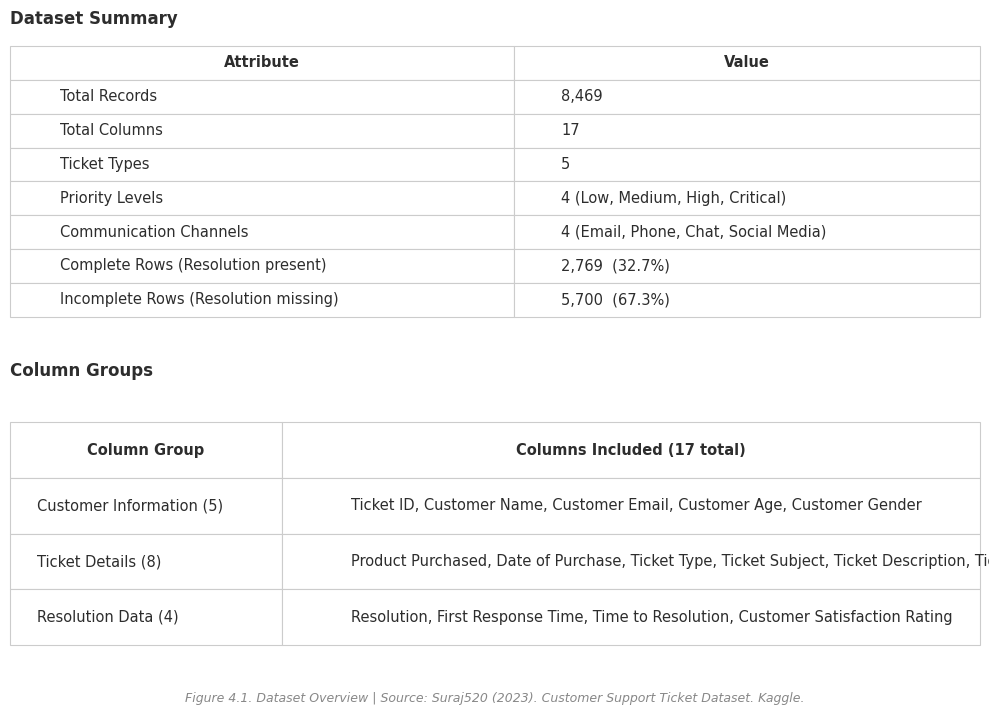

Figure 4.1 saved.


In [ ]:
# ── Dataset Overview — Figure 4.1 ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 7))
fig.patch.set_facecolor('white')

ax_top = axes[0]
ax_top.axis('off')
summary_data = [
    ['Total Records', '8,469'],
    ['Total Columns', '17'],
    ['Ticket Types', '5'],
    ['Priority Levels', '4 (Low, Medium, High, Critical)'],
    ['Communication Channels', '4 (Email, Phone, Chat, Social Media)'],
    ['Complete Rows (Resolution present)', '2,769  (32.7%)'],
    ['Incomplete Rows (Resolution missing)', '5,700  (67.3%)'],
]
t1 = ax_top.table(cellText=summary_data, colLabels=['Attribute', 'Value'],
                   cellLoc='left', loc='center', colWidths=[0.52, 0.48])
t1.auto_set_font_size(False)
t1.set_fontsize(10.5)
t1.scale(1, 1.7)
for (row, col), cell in t1.get_celld().items():
    cell.set_edgecolor(G['border'])
    cell.set_linewidth(0.8)
    cell.set_facecolor(G['white'])
    if row == 0:
        cell.set_text_props(fontweight='bold', color=G['dark'])
    else:
        cell.set_text_props(color=G['dark'])
ax_top.set_title('Dataset Summary', fontsize=12, fontweight='bold',
                  color=G['dark'], pad=8, loc='left')

ax_bot = axes[1]
ax_bot.axis('off')
col_data = [
    ['Customer Information (5)',
     'Ticket ID, Customer Name, Customer Email, Customer Age, Customer Gender'],
    ['Ticket Details (8)',
     'Product Purchased, Date of Purchase, Ticket Type, Ticket Subject, '
     'Ticket Description, Ticket Status, Ticket Priority, Ticket Channel'],
    ['Resolution Data (4)',
     'Resolution, First Response Time, Time to Resolution, Customer Satisfaction Rating'],
]
t2 = ax_bot.table(cellText=col_data, colLabels=['Column Group', 'Columns Included (17 total)'],
                   cellLoc='left', loc='center', colWidths=[0.28, 0.72])
t2.auto_set_font_size(False)
t2.set_fontsize(10.5)
t2.scale(1, 2.8)
for (row, col), cell in t2.get_celld().items():
    cell.set_edgecolor(G['border'])
    cell.set_linewidth(0.8)
    cell.set_facecolor(G['white'])
    if row == 0:
        cell.set_text_props(fontweight='bold', color=G['dark'])
    else:
        cell.set_text_props(color=G['dark'])
ax_bot.set_title('Column Groups', fontsize=12, fontweight='bold',
                  color=G['dark'], pad=8, loc='left')

fig.text(0.5, -0.01,
    'Figure 4.1. Dataset Overview | Source: Suraj520 (2023). Customer Support Ticket Dataset. Kaggle.',
    ha='center', fontsize=9, color=G['medium'], style='italic')
plt.tight_layout(h_pad=2.5)
plt.savefig('figure_4_1_dataset_overview.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure 4.1 saved.')

---
## Single Record Preview
A preview of what every record looks like — all 17 columns for one ticket entry.

In [ ]:
# ── Single row preview — all 17 columns ───────────────────────────────────
pd.set_option('display.max_colwidth', 60)
df.iloc[[0]].T.rename(columns={0: 'Row 1'})

,Row 1
Ticket ID,1
Customer Name,Marisa Obrien
Customer Email,carrollallison@example.com
Customer Age,32
Customer Gender,Other
Product Purchased,GoPro Hero
Date of Purchase,2021-03-22
Ticket Type,Technical issue
Ticket Subject,Product setup
Ticket Description,I'm having an issue with the {product_purchased}. Please...


---
## Dataset Preprocessing
The following four cells correspond to the four preprocessing steps described in Chapter 4. Each cell produces the supporting figure referenced in the thesis.

### Step 1 — Remove Exact Duplicate Rows (Figure 4.4)
Check all 17 columns for identical records. Result used to confirm dataset integrity before evaluation.

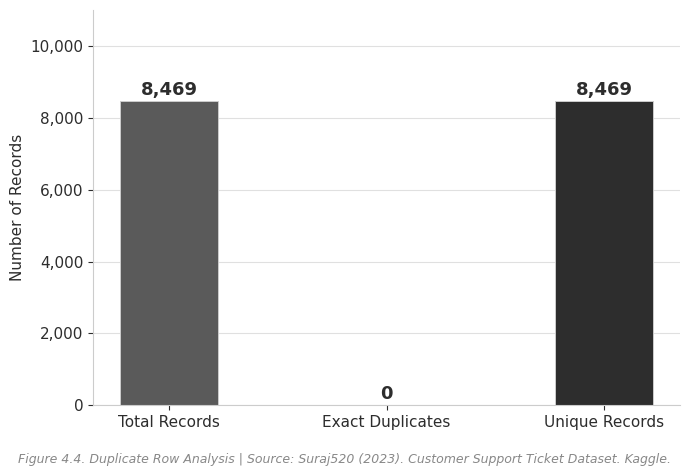

Figure 4.4 saved. | Exact duplicates: 0 | Unique rows: 8469


In [ ]:
# ── Duplicate Row Analysis — Figure 4.4 ───────────────────────────────────
exact_duplicates = df.duplicated().sum()
unique_rows = len(df) - exact_duplicates

fig, ax = plt.subplots(figsize=(7, 4.5))
fig.patch.set_facecolor('white')
categories = ['Total Records', 'Exact Duplicates', 'Unique Records']
values = [len(df), exact_duplicates, unique_rows]
bar_colors = [G['mid'], G['light'], G['dark']]
bars = ax.bar(categories, values, color=bar_colors, width=0.45,
              edgecolor=G['border'], linewidth=0.7, zorder=2)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom',
            fontweight='bold', fontsize=13, color=G['dark'])
ax.set_ylabel('Number of Records', fontsize=11, color=G['dark'])
ax.set_ylim(0, 11000)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', color=G['vlight'], linewidth=0.8, zorder=1)
ax.tick_params(labelsize=11, colors=G['dark'])
ax.spines['left'].set_color(G['border'])
ax.spines['bottom'].set_color(G['border'])
fig.text(0.5, -0.04,
    'Figure 4.4. Duplicate Row Analysis | Source: Suraj520 (2023). Customer Support Ticket Dataset. Kaggle.',
    ha='center', fontsize=9, color=G['medium'], style='italic')
plt.tight_layout()
plt.savefig('figure_4_4_duplicate_analysis.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'Figure 4.4 saved. | Exact duplicates: {exact_duplicates} | Unique rows: {unique_rows}')

### Step 2 — Filter by Ticket Type for Category 1 (Figure 4.2)
The full 8,469-record dataset is used for Category 1, filtered by Ticket Type. This figure confirms all five ticket type values are present and approximately evenly distributed.

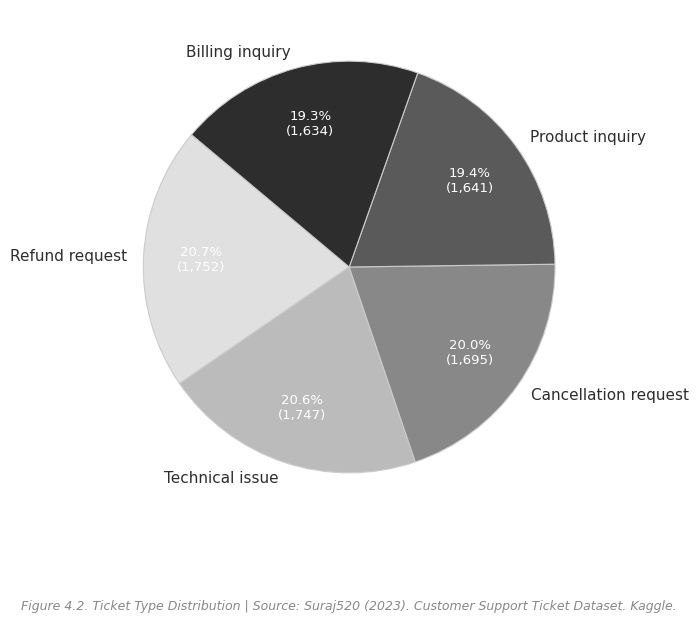

Figure 4.2 saved.


In [ ]:
# ── Ticket Type Distribution — Figure 4.2 ─────────────────────────────────
type_counts = df['Ticket Type'].value_counts()
n = len(type_counts)
gray_shades = [G['vlight'], G['light'], G['medium'], G['mid'], G['dark']]

fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor('white')

wedges, texts, autotexts = ax.pie(
    type_counts.values,
    labels=type_counts.index,
    colors=gray_shades[:n],
    autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct/100 * len(df))):,})',
    startangle=140,
    wedgeprops=dict(edgecolor=G['border'], linewidth=0.8),
    pctdistance=0.72,
    labeldistance=1.08,
)
for text in texts:
    text.set_fontsize(11)
    text.set_color(G['dark'])
for autotext in autotexts:
    autotext.set_fontsize(9.5)
    autotext.set_color('white')

fig.text(0.5, 0.01,
    'Figure 4.2. Ticket Type Distribution | Source: Suraj520 (2023). Customer Support Ticket Dataset. Kaggle.',
    ha='center', fontsize=9, color=G['medium'], style='italic')
plt.tight_layout()
plt.savefig('figure_4_2_ticket_type_distribution.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure 4.2 saved.')

### Step 3 — Sample Records for Category 2 (Figure 4.6)
2,769 records with non-empty Resolution fields are identified for the AI vs. human comparison. 200 records are sampled at random to form the Category 2 evaluation set.

Complete rows (Description + Resolution present): 2769 (32.7%)
Incomplete rows (Description present, no Resolution): 5700 (67.3%)


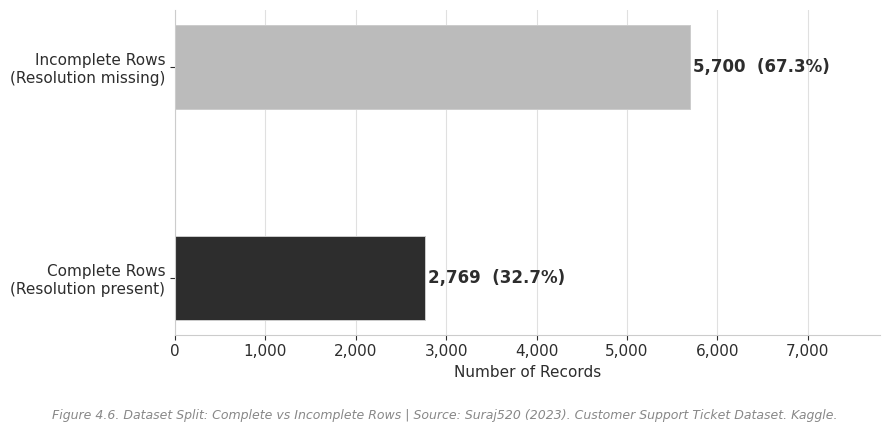

Figure 4.6 saved.


In [ ]:
# ── Dataset Split: Complete vs Incomplete — Figure 4.6 ────────────────────
complete = df[df['Resolution'].notna() & df['Ticket Description'].notna()]
incomplete = df[df['Resolution'].isna() & df['Ticket Description'].notna()]

print(f'Complete rows (Description + Resolution present): {len(complete)} ({round(len(complete)/len(df)*100,1)}%)')
print(f'Incomplete rows (Description present, no Resolution): {len(incomplete)} ({round(len(incomplete)/len(df)*100,1)}%)')

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('white')
groups = ['Complete Rows\n(Resolution present)', 'Incomplete Rows\n(Resolution missing)']
counts = [len(complete), len(incomplete)]
bar_colors = [G['dark'], G['light']]
bars = ax.barh(groups, counts, color=bar_colors, height=0.4,
               edgecolor=G['border'], linewidth=0.7, zorder=2)
for bar, val in zip(bars, counts):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({val/len(df)*100:.1f}%)',
            va='center', fontsize=12, fontweight='bold', color=G['dark'])
ax.set_xlabel('Number of Records', fontsize=11, color=G['dark'])
ax.set_xlim(0, 7800)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', color=G['vlight'], linewidth=0.8, zorder=1)
ax.tick_params(labelsize=11, colors=G['dark'])
ax.spines['left'].set_color(G['border'])
ax.spines['bottom'].set_color(G['border'])
fig.text(0.5, -0.06,
    'Figure 4.6. Dataset Split: Complete vs Incomplete Rows | Source: Suraj520 (2023). Customer Support Ticket Dataset. Kaggle.',
    ha='center', fontsize=9, color=G['medium'], style='italic')
plt.tight_layout()
plt.savefig('figure_4_6_dataset_split.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure 4.6 saved.')

### Step 4 — Filter Records for Category 6 (Figure 4.7)
Records with non-empty First Response Time are identified as the human response-time baseline for Category 6.

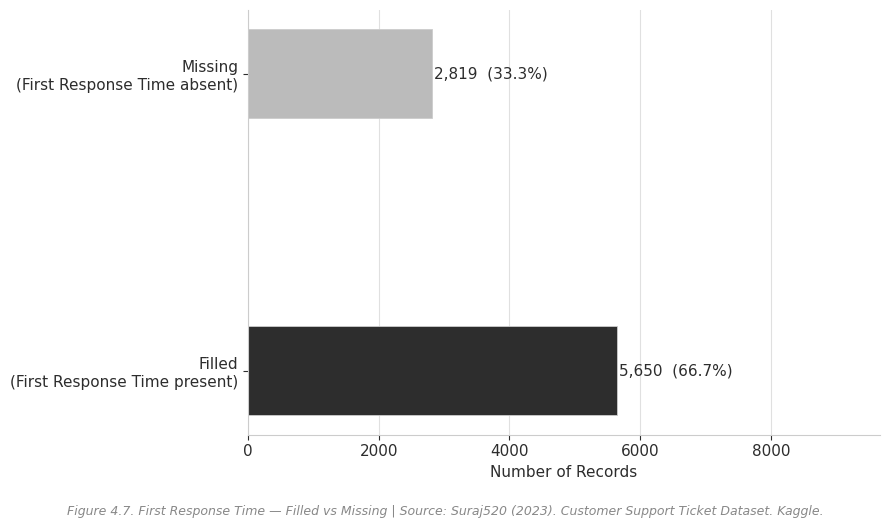

Figure 4.7 saved. | Filled: 5,650 (66.7%)  |  Missing: 2,819 (33.3%)


In [ ]:
# ── First Response Time — filled vs missing — Figure 4.7 ──────────────────
filled = df['First Response Time'].notna().sum()
missing = df['First Response Time'].isna().sum()
total = len(df)

labels = ['Filled\n(First Response Time present)', 'Missing\n(First Response Time absent)']
values = [filled, missing]
colors = [G['dark'], G['light']]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('white')
bars = ax.barh(labels, values, color=colors, height=0.30,
               edgecolor=G['border'], linewidth=0.6, zorder=2)
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({val/total*100:.1f}%)',
            va='center', fontsize=11, color=G['dark'])
ax.set_xlabel('Number of Records', fontsize=11, color=G['dark'])
ax.set_xlim(0, total + 1200)
ax.grid(axis='x', color=G['vlight'], linewidth=0.8, zorder=1)
ax.tick_params(labelsize=11, colors=G['dark'])
ax.spines['left'].set_color(G['border'])
ax.spines['bottom'].set_color(G['border'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.text(0.5, -0.04,
    'Figure 4.7. First Response Time — Filled vs Missing | Source: Suraj520 (2023). Customer Support Ticket Dataset. Kaggle.',
    ha='center', fontsize=9, color=G['medium'], style='italic')
plt.tight_layout()
plt.savefig('figure_4_7_first_response_time_split.png', dpi=180, bbox_inches='tight')
plt.show()
print(f'Figure 4.7 saved. | Filled: {filled:,} ({filled/total*100:.1f}%)  |  Missing: {missing:,} ({missing/total*100:.1f}%)')

---
## Appendix A — Additional Dataset Statistics
Supplementary figures providing further dataset detail. Referenced in Appendix A of the thesis: ticket priority distribution, communication channel breakdown, missing values analysis, and resolution length statistics.

### Missing Values per Column (Figure A.1)
Percentage of missing values for columns that contain at least one missing value.

In [ ]:
# ── Missing Values per Column — Figure A.1 ────────────────────────────────
missing = df.isnull().sum()
missing_pct = round(missing / len(df) * 100, 1)
missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Missing Values', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('white')
bar_colors = [G['light'] if p < 50 else G['dark'] for p in missing_df['Percentage']]
bars = ax.barh(missing_df.index, missing_df['Percentage'],
               color=bar_colors, height=0.5,
               edgecolor=G['border'], linewidth=0.6, zorder=2)
for bar, val, count in zip(bars, missing_df['Percentage'], missing_df['Missing Values']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%  ({count:,} rows)', va='center', fontsize=11, color=G['dark'])
ax.set_xlabel('Percentage of Missing Values (%)', fontsize=11, color=G['dark'])
ax.set_xlim(0, 95)
ax.grid(axis='x', color=G['vlight'], linewidth=0.8, zorder=1)
ax.tick_params(labelsize=11, colors=G['dark'])
ax.spines['left'].set_color(G['border'])
ax.spines['bottom'].set_color(G['border'])
legend_elements = [
    mpatches.Patch(color=G['dark'], label='> 50% missing'),
    mpatches.Patch(color=G['light'], label='< 50% missing'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          framealpha=0.9, edgecolor=G['border'])
fig.text(0.5, -0.06,
    'Figure A.1. Missing Values per Column | Source: Suraj520 (2023). Customer Support Ticket Dataset. Kaggle.',
    ha='center', fontsize=9, color=G['medium'], style='italic')
plt.tight_layout()
plt.savefig('figure_A1_missing_values.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure A.1 saved.')
print(f'\nTotal rows with at least one missing value: {df.isnull().any(axis=1).sum()} out of {len(df)}')

### Ticket Description Length Distribution (Figure A.2)

In [ ]:
# ── Ticket Description Length Distribution — Figure A.2 ───────────────────
df['description_word_count'] = df['Ticket Description'].fillna('').apply(lambda x: len(x.split()))
avg = df['description_word_count'].mean()
median = df['description_word_count'].median()

print(f'Ticket Description length (word count):')
print(f'  Average: {avg:.1f} words | Median: {median:.0f} words')
print(f'  Minimum: {df["description_word_count"].min()} words | Maximum: {df["description_word_count"].max()} words')
print(f'  Tickets shorter than 10 words: {(df["description_word_count"] < 10).sum()}')
print(f'  Tickets longer than 100 words: {(df["description_word_count"] > 100).sum()}')

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('white')
ax.hist(df['description_word_count'], bins=30, color=G['mid'],
        edgecolor='white', linewidth=0.5, zorder=2)
ax.axvline(avg, color=G['dark'], linewidth=2, linestyle='--', label=f'Mean: {avg:.1f} words')
ax.axvline(median, color=G['light'], linewidth=2, linestyle=':', label=f'Median: {median:.0f} words')
ax.set_xlabel('Word Count (Ticket Description)', fontsize=11, color=G['dark'])
ax.set_ylabel('Number of Tickets', fontsize=11, color=G['dark'])
ax.legend(fontsize=10, framealpha=0.9, edgecolor=G['border'])
ax.grid(axis='y', color=G['vlight'], linewidth=0.8, zorder=1)
ax.tick_params(labelsize=11, colors=G['dark'])
ax.spines['left'].set_color(G['border'])
ax.spines['bottom'].set_color(G['border'])
fig.text(0.5, -0.04,
    'Figure A.2. Ticket Description Length Distribution | Source: Suraj520 (2023). Customer Support Ticket Dataset. Kaggle.',
    ha='center', fontsize=9, color=G['medium'], style='italic')
plt.tight_layout()
plt.savefig('figure_A2_description_length.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure A.2 saved.')

### Resolution Length Distribution (Figure A.3)

In [ ]:
# ── Resolution Length Distribution — Figure A.3 ───────────────────────────
resolved = df[df['Resolution'].notna()].copy()
resolved['resolution_word_count'] = resolved['Resolution'].apply(lambda x: len(str(x).split()))
avg_r = resolved['resolution_word_count'].mean()

print(f'Resolution length — human agent answers:')
print(f'  Average: {avg_r:.1f} words | Median: {resolved["resolution_word_count"].median():.0f} words')
print(f'  Minimum: {resolved["resolution_word_count"].min()} | Maximum: {resolved["resolution_word_count"].max()} words')

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('white')
ax.hist(resolved['resolution_word_count'], bins=20, color=G['mid'],
        edgecolor='white', linewidth=0.5, zorder=2)
ax.axvline(avg_r, color=G['dark'], linewidth=2, linestyle='--', label=f'Mean: {avg_r:.1f} words')
ax.set_xlabel('Word Count (Resolution)', fontsize=11, color=G['dark'])
ax.set_ylabel('Number of Tickets', fontsize=11, color=G['dark'])
ax.legend(fontsize=10, framealpha=0.9, edgecolor=G['border'])
ax.grid(axis='y', color=G['vlight'], linewidth=0.8, zorder=1)
ax.tick_params(labelsize=11, colors=G['dark'])
ax.spines['left'].set_color(G['border'])
ax.spines['bottom'].set_color(G['border'])
fig.text(0.5, -0.04,
    'Figure A.3. Resolution Length Distribution | Source: Suraj520 (2023). Customer Support Ticket Dataset. Kaggle.',
    ha='center', fontsize=9, color=G['medium'], style='italic')
plt.tight_layout()
plt.savefig('figure_A3_resolution_length.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure A.3 saved.')

### Ticket Priority Distribution (Figure A.4)

In [ ]:
# ── Ticket Priority Distribution — Figure A.4 ─────────────────────────────
priority_order = ['Low', 'Medium', 'High', 'Critical']
priority_counts = df['Ticket Priority'].value_counts().reindex(priority_order)
gray_shades4 = [G['vlight'], G['light'], G['mid'], G['dark']]

fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor('white')
bars = ax.barh(priority_counts.index, priority_counts.values,
               color=gray_shades4, height=0.5,
               edgecolor=G['border'], linewidth=0.6, zorder=2)
for bar, val in zip(bars, priority_counts.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({val/len(df)*100:.1f}%)',
            va='center', fontsize=11, color=G['dark'])
ax.set_xlabel('Number of Tickets', fontsize=11, color=G['dark'])
ax.set_xlim(0, 2800)
ax.grid(axis='x', color=G['vlight'], linewidth=0.8, zorder=1)
ax.tick_params(labelsize=11, colors=G['dark'])
ax.spines['left'].set_color(G['border'])
ax.spines['bottom'].set_color(G['border'])
fig.text(0.5, -0.04,
    'Figure A.4. Ticket Priority Distribution | Source: Suraj520 (2023). Customer Support Ticket Dataset. Kaggle.',
    ha='center', fontsize=9, color=G['medium'], style='italic')
plt.tight_layout()
plt.savefig('figure_A4_priority_distribution.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure A.4 saved.')

### Ticket Channel Distribution (Figure A.5)

In [ ]:
# ── Ticket Channel Distribution — Figure A.5 ──────────────────────────────
channel_counts = df['Ticket Channel'].value_counts().sort_values()
gray_shades4c = [G['vlight'], G['light'], G['mid'], G['dark']]

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('white')
bars = ax.barh(channel_counts.index, channel_counts.values,
               color=gray_shades4c, height=0.45,
               edgecolor=G['border'], linewidth=0.6, zorder=2)
for bar, val in zip(bars, channel_counts.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({val/len(df)*100:.1f}%)',
            va='center', fontsize=11, color=G['dark'])
ax.set_xlabel('Number of Tickets', fontsize=11, color=G['dark'])
ax.set_xlim(0, 2800)
ax.grid(axis='x', color=G['vlight'], linewidth=0.8, zorder=1)
ax.tick_params(labelsize=11, colors=G['dark'])
ax.spines['left'].set_color(G['border'])
ax.spines['bottom'].set_color(G['border'])
fig.text(0.5, -0.04,
    'Figure A.5. Ticket Channel Distribution | Source: Suraj520 (2023). Customer Support Ticket Dataset. Kaggle.',
    ha='center', fontsize=9, color=G['medium'], style='italic')
plt.tight_layout()
plt.savefig('figure_A5_channel_distribution.png', dpi=180, bbox_inches='tight')
plt.show()
print('Figure A.5 saved.')